# Bayesian inference: tracking a changing world state
__Author: [Florent Meyniel](https://florentmeyniel.weebly.com/), NeuroSpin (CEA Paris Saclay) and INM (GHU Paris Psychiatrie et neuroscience)__

[The Computational Brain Team](https://computationalbrainteam.com)

## The problem to solve: how should the brain track a world state that changes over time?

Imagine tracking the direction the wind is blowing from, using only a noisy weather vane. The true wind direction (*s<sub>t</sub>*, a compass angle) is not constant. We will distinguish two ways in which it can change: it can either **drift** gradually from one moment to the next, or **change abruptly** when a new weather front comes through. All you get to observe is a noisy reading (*y<sub>t</sub>*) of that direction. We can summarize the generative process as follows.

*Evolution*: world state (*s<sub>t</sub>*) -> [change point / drift] -> world state (*s<sub>t+1</sub>*)

*Observation*: world state (*s<sub>t</sub>*) -> [noisy weather vane] -> observation (*y<sub>t</sub>*)


The brain (or any observer) only has access to the sequence of noisy observations *y<sub>1:t</sub>* and must infer the current world state *s<sub>t</sub>*, ideally combined with some notion of how volatile the world is. This notebook uses a Bayesian algorithm for this problem. It uses this example to introduce the notion of an **apparent learning rate**: how much weight a learner effectively places on a new observation, and how a simple delta rule can (or cannot) approximate this optimal behavior.

This setup, and the change-point / drift distinction in particular, is central to the study of learning under volatility:

- Piray, Payam, and Nathaniel D. Daw. 2024. “Computational Processes of Simultaneous Learning of Stochasticity and Volatility in Humans.” Nature Communications
- Nassar, Matthew R., Robert C. Wilson, Benjamin Heasly, and Joshua I. Gold. 2010. “An Approximately Bayesian Delta-Rule Model Explains the Dynamics of Belief Updating in a Changing Environment.” The Journal of Neuroscience
- Foucault, Cedric, and Florent Meyniel. 2024. “Two Determinants of Dynamic Adaptive Learning for Magnitudes and Probabilities.” Open Mind 8

## Initialize notebook

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

## Section 1 -- Helper functions

You can skip this section if you are not interested in the mathematical details and the implementation.

### Discretizing a circular latent state

We discretize the wind direction on a regular grid of `n_grid` compass angles between 0 deg and 360 deg, and represent every probability distribution over the wind direction as a vector of probabilities on this grid (a discrete approximation of a continuous circular density). We use a grid because the product of the likelihood and the prior used for the inference here does not follow a known analytical solution. We therefore compute the inference numerically (by discretizing over a grid) rather than analytically.

Because the state lives on a circle, ordinary subtraction is wrong close to the 0deg/360deg boundary (e.g. 359deg and 1deg are only 2deg apart, not 358deg). We therefore need a **circular difference** that always returns the shortest signed distance around the circle, and a **circular Gaussian** likelihood built on top of it (a "wrapped" Gaussian, using a wrap-to-nearest approximation -- accurate as long as the SD stays well below a quarter of the circle, which holds throughout this notebook, where SDs never exceed 60deg).

In [2]:
def circ_diff(a, b, period=360.0):
    """Signed circular difference a-b, wrapped to (-period/2, period/2]."""
    return (np.asarray(a, dtype=float) - np.asarray(b, dtype=float) + period / 2) % period - period / 2


def circ_gaussian_pdf(grid_deg, mu, sigma, period=360.0):
    """Circular ('wrapped') Gaussian, unnormalized, evaluated at each point of grid_deg.
    Uses a wrap-to-nearest approximation to the true wrapped normal, which is accurate
    as long as sigma stays well below period/4 (true for every sigma used here, <=60 deg)."""
    return norm.pdf(circ_diff(grid_deg, mu, period), loc=0, scale=sigma)


def circular_mean(grid_deg, prob, period=360.0):
    """Circular mean (resultant-vector average) of one or several discrete distributions
    over grid_deg. prob can be 1D (n_grid,) for a single distribution, or 2D (T, n_grid)
    for a batch of T distributions (e.g. the output of bayesian_inference)."""
    prob = np.asarray(prob, dtype=float)
    prob = prob / prob.sum(axis=-1, keepdims=True)
    theta = 2 * np.pi * grid_deg / period
    C = np.sum(prob * np.cos(theta), axis=-1)
    S = np.sum(prob * np.sin(theta), axis=-1)
    return (period / (2 * np.pi)) * (np.arctan2(S, C) % (2 * np.pi))

### Two ways the world can change: change points and drift

Between two observations, the wind direction evolves according to a **transition matrix** `T`, where `T[i, j]` is the probability of moving from grid state `i` to grid state `j`. We consider two qualitatively different regimes, controlled by a single **volatility** parameter:

- **Change point** (`volatility_param` = per-trial probability of a change point, *p*): with probability `1-p` the latent wind direction stays exactly the same; with probability `p` it jumps to a uniformly random new direction (a new weather front). This gives a transition matrix with a high value on the diagonal and a small uniform value everywhere else.
- **Drift** (`volatility_param` = the drift SD, in degrees): the wind direction takes a small circular-Gaussian step around its current value on every trial. This gives a transition matrix with a Gaussian-shaped bump around the diagonal.

We implement both regimes with a single function, selected by a `volatility_type` argument, because in both cases in the end we need the same object: a transition matrix. 

In [3]:
def build_transition_matrix(grid_deg, volatility_type, volatility_param, period=360.0):
    """Row-stochastic transition matrix T[i, j] = P(s_(t+1)=grid_deg[j] | s_t=grid_deg[i]),
    single entry point for both volatility regimes.
    volatility_type='changepoint': volatility_param = per-trial change-point probability p;
        (1-p) on the diagonal (no change point), uniform everywhere else (change point
        -> new direction drawn uniformly at random).
    volatility_type='drift': volatility_param = drift SD in degrees; each row is a circular
        Gaussian bump of that SD centered on the diagonal."""
    n = len(grid_deg)
    if volatility_type == 'changepoint':
        p = volatility_param
        T = (1 - p) * np.eye(n) + (p / n) * np.ones((n, n))
    elif volatility_type == 'drift':
        D = circ_diff(grid_deg[None, :], grid_deg[:, None], period)
        T = norm.pdf(D, loc=0, scale=volatility_param)
        T = T / T.sum(axis=1, keepdims=True)
    else:
        raise ValueError("volatility_type must be 'changepoint' or 'drift'")
    return T

### Bayesian inference

At every trial, the observer's belief about the wind direction is updated in two steps:

1. **Update**: combine the current belief (prior, $p(s_t \mid y_{1:t-1})$) with the likelihood of the new observation $y_t$ -- a circular Gaussian centered on $y_t$, with SD equal to the observer's assumed level of sensory noise ("stochasticity") -- to obtain the posterior $p(s_t \mid y_{1:t}) \propto p(s_t \mid y_{1:t-1}) \, p(y_t \mid s_t)$.
2. **Predict**: propagate the posterior from one observation to the next, under the assumption that the latent world state can change (following a change point or a drift). Formally, the possible world states are described by the transition matrix, and the possible change in world state obtained by multiplying the current prior with the transition matrix, resulting in the next trial's prior, $p(s_{t+1} \mid y_{1:t}) = \sum_{s_t} p(s_t \mid y_{1:t}) \, T(s_t \to s_{t+1})$.

Throughout this notebook, unless stated otherwise, the observer is an **ideal observer**: the generative model that it assumes is the actual generative process, and it computes following the laws of probability calculus.

In [4]:
def bayesian_inference(observations, grid_deg, transition_matrix, sigma_assumed, prior0=None):
    """Grid-based recursive Bayesian algorithm for a circular latent state.
    Returns (posteriors, priors), each of shape (T, n_grid):
    priors[t] = predictive p(s_t | y_1:t-1), BEFORE observation t;
    posteriors[t] = p(s_t | y_1:t), AFTER combining priors[t] with the circular-Gaussian
    likelihood of observations[t] (SD=sigma_assumed) and normalizing.
    prior0 defaults to a uniform prior over the grid."""
    n = len(grid_deg)
    prior = np.ones(n) / n if prior0 is None else np.array(prior0, dtype=float).copy()
    T_obs = len(observations)
    priors = np.zeros((T_obs, n))
    posteriors = np.zeros((T_obs, n))
    for t, y in enumerate(observations):
        # store the current prior
        priors[t] = prior

        # compute posterior inference by combining prior and likelihood
        lik = circ_gaussian_pdf(grid_deg, y, sigma_assumed)
        post = prior * lik
        post /= post.sum()
        posteriors[t] = post

        # the current posterior becomes the next prior
        # the posterior is updated, in the absence of a new observer,
        # under the assumption that the latent may change from one
        # observation to the next
        prior = post @ transition_matrix
    return posteriors, priors

### Generating a sequence of observations

To test the Bayesian inference algorithm, we simulate a "ground truth" wind direction that evolves according to one of the two volatility regimes above, plus a noisy observation of it on every trial (observation-noise SD = "stochasticity").

In [5]:
def generate_sequence(T, volatility_type, volatility_param, sigma_obs, s0=None, period=360.0):
    """Generate a latent circular trajectory and noisy observations.
    volatility_type in {'changepoint', 'drift'}; volatility_param = per-trial change-point
    probability, or per-trial drift SD (deg); sigma_obs = observation-noise SD (deg).
    Returns {'s': true trajectory, 'y': observations, 'changepoints': trial indices with a
    change point (empty array for 'drift')}."""
    s = np.zeros(T)
    changepoints = []
    s[0] = np.random.rand() * period if s0 is None else s0
    for t in range(1, T):
        if volatility_type == 'changepoint':
            if np.random.rand() < volatility_param:
                # resample the latent true direction
                s[t] = np.random.rand() * period
                changepoints.append(t)
            else:
                s[t] = s[t - 1]
        elif volatility_type == 'drift':
            # randomly drift the latent true direction
            s[t] = (s[t - 1] + np.random.randn() * volatility_param) % period
        else:
            raise ValueError("volatility_type must be 'changepoint' or 'drift'")

    # add observation noise
    y = (s + np.random.randn(T) * sigma_obs) % period
    return {'s': s, 'y': y, 'changepoints': np.array(changepoints, dtype=int)}

### A small plotting utility

Plot the latent true direction and the estimated direction (the current direction is indicated on a 1D segment, but knowing that values wrap around the circle).

In [6]:
def break_circular_line(y, period=360.0):
    """Return a copy of y (a sequence of angles in degrees) with NaN inserted wherever
    consecutive values jump by more than period/2, so a line plot does not draw a
    spurious segment across the 0/period wraparound. Same length as y; only line
    continuity is affected, not the underlying data."""
    y = np.asarray(y, dtype=float).copy()
    jumps = np.where(np.abs(np.diff(y)) > period / 2)[0]
    y[jumps + 1] = np.nan
    return y

In [7]:
n_grid = 144
grid_deg = np.linspace(0, 360, n_grid, endpoint=False)

np.random.seed(0)

## Section 2 -- Demo: how the posterior evolves, from individual curves to a heat map

We simulate a **100-trial** change-point sequence (change-point probability = 3/100, i.e. about 3 change points on average) and track the posterior belief over the wind direction, trial by trial. To keep the demo reproducible and pedagogically clean, we search over random seeds for one that produces exactly 3 change points, reasonably spaced across the sequence (rather than hand-placing the change points), and fix that seed.

In [8]:
def find_demo_seed(T=100, p_cp=0.03, sigma_obs=15.0, n_cp_target=3, min_gap=15, max_seed=20000):
    """Search random seeds for a change-point sequence with exactly n_cp_target change
    points, each separated (and separated from the sequence edges) by at least min_gap
    trials. Returns the first matching (seed, sequence), for a clean, reproducible demo."""
    for seed in range(max_seed):
        np.random.seed(seed)
        seq = generate_sequence(T, 'changepoint', p_cp, sigma_obs)
        cps = seq['changepoints']
        if len(cps) != n_cp_target:
            continue
        gaps = np.diff(np.r_[0, cps, T])
        if np.min(gaps) >= min_gap:
            return seed, seq
    raise RuntimeError('No seed found matching the criteria within max_seed tries.')


p_cp_demo = 0.03
sigma_obs_demo = 15.0

demo_seed, demo_seq = find_demo_seed(p_cp=p_cp_demo, sigma_obs=sigma_obs_demo)
print(f"chosen seed = {demo_seed}, change points at trials {demo_seq['changepoints']}")

chosen seed = 171, change points at trials [29 64 79]


In [9]:
T_changepoint_demo = build_transition_matrix(grid_deg, 'changepoint', p_cp_demo)
demo_posteriors, demo_priors = bayesian_inference(demo_seq['y'], grid_deg, T_changepoint_demo, sigma_obs_demo)

### The generated sequence

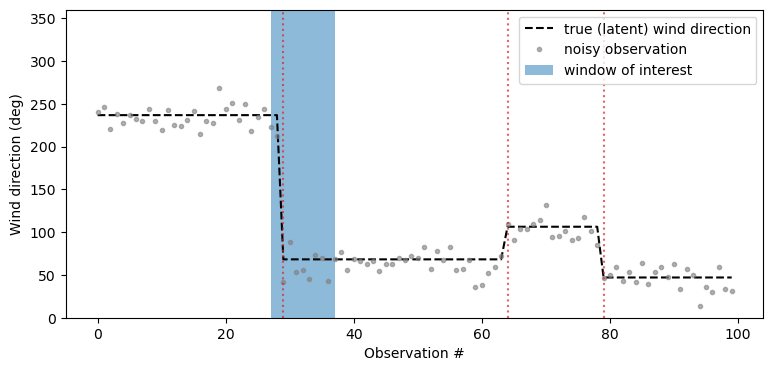

In [27]:
plt.plot(break_circular_line(demo_seq['s']), 'k--', label='true (latent) wind direction')
plt.plot(demo_seq['y'], '.', color='tab:gray', label='noisy observation', alpha=0.6)
for cp in demo_seq['changepoints']:
    plt.axvline(cp, color='tab:red', linestyle=':', alpha=0.7)

# highlight a specific window
window_start = max(0, demo_seq['changepoints'][0] - 2)
window_size=10
window = np.arange(window_start, window_start + window_size)
plt.fill([window_start, window_start, window_start+window_size, window_start+window_size],
         [0, 360, 360, 0], alpha=0.5, label='window of interest')

plt.xlabel('Observation #')
plt.ylabel('Wind direction (deg)')
plt.ylim(0, 360)
plt.legend(loc='upper right')
fig = plt.gcf()
fig.set_size_inches(9, 4)
fig.savefig('output/bayesian_filtering_demo_sequence.svg')

### From individual posteriors...

Before looking at the full time course, let's look closely at a window of interest: 10 consecutive posteriors around the first change point, superimposed on the same axis (the blue window in the above plot). Below, each curve is the posterior distribution over the wind direction after one observation; its color encodes the observation number (a smooth gradient from early/dark to late/bright).

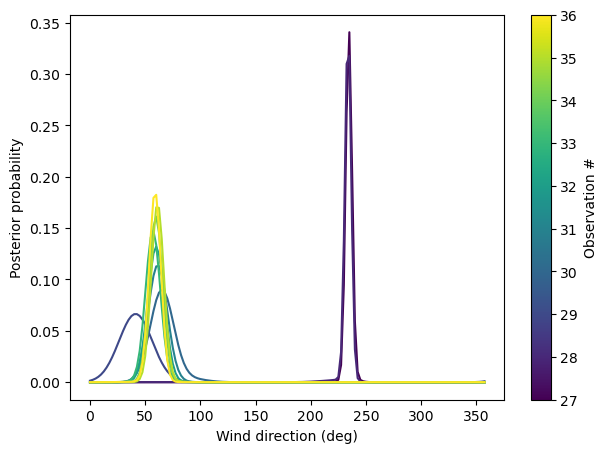

In [11]:
cmap = plt.get_cmap('viridis')
fig, ax = plt.subplots(figsize=(7, 5))
for k, t in enumerate(window):
    ax.plot(grid_deg, demo_posteriors[t], color=cmap(k / (len(window) - 1)))
ax.set_xlabel('Wind direction (deg)')
ax.set_ylabel('Posterior probability')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(window[0], window[-1]))
fig.colorbar(sm, ax=ax, label='Observation #')
fig.savefig('output/bayesian_filtering_demo_superimposed_posteriors.svg')

### ...to the full heat map

The above plot is not very convenient: reading the observation number is difficult because it is coded by a color gradiant, and the posterior distributions are difficult to see when they overlap, which inevitably happens as the seuqence length increases. 

The same posteriors are now shown for all 100 trials as a heat map (observation number on the x-axis, wind direction on the y-axis, color = posterior probability). The white dashed line is the true wind direction. You should recognize, in this heat map, the same kind of posterior curves you just saw superimposed above -- read as vertical slices (in which the color now code the posterior distribution).

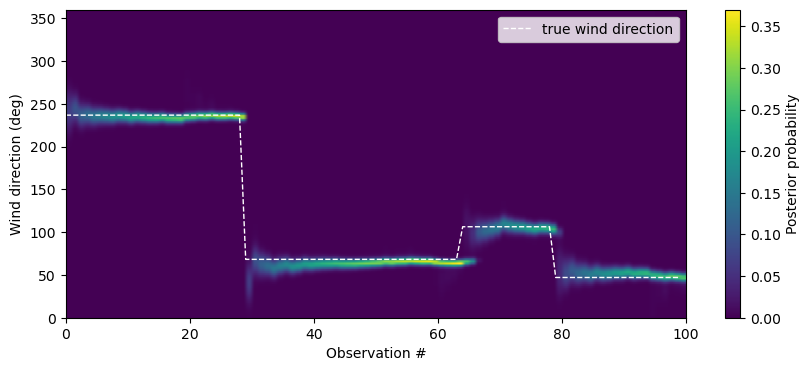

In [12]:
spacing = grid_deg[1] - grid_deg[0]
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(demo_posteriors.T, aspect='auto', origin='lower', cmap='viridis',
               extent=[0, len(demo_seq['y']), grid_deg[0], grid_deg[-1] + spacing])
ax.plot(break_circular_line(demo_seq['s']), '--', color='white', linewidth=1, label='true wind direction')
ax.set_xlabel('Observation #')
ax.set_ylabel('Wind direction (deg)')
ax.legend(loc='upper right')
fig.colorbar(im, ax=ax, label='Posterior probability')
fig.savefig('output/bayesian_filtering_demo_heatmap.svg')

## Section 3 -- Comparing change points and drift

We now compare the two volatility regimes side by side.

### Example sequences and posterior heat maps

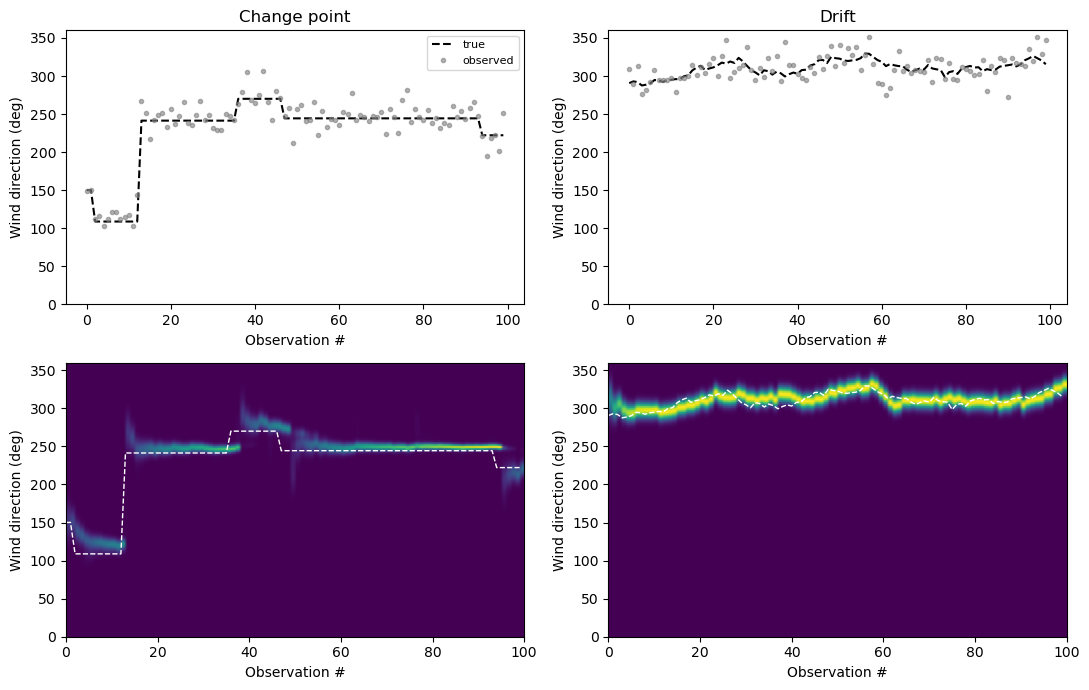

In [37]:
T_compare = 100
sigma_obs_compare = 15.0

sigma_drift_matched = 3.4

np.random.seed(1)
seq_changepoint = generate_sequence(T_compare, 'changepoint', p_cp_demo, sigma_obs_compare)
seq_drift = generate_sequence(T_compare, 'drift', sigma_drift_matched, sigma_obs_compare)

Tmat_changepoint = build_transition_matrix(grid_deg, 'changepoint', p_cp_demo)
Tmat_drift = build_transition_matrix(grid_deg, 'drift', sigma_drift_matched)

post_changepoint, _ = bayesian_inference(seq_changepoint['y'], grid_deg, Tmat_changepoint, sigma_obs_compare)
post_drift, _ = bayesian_inference(seq_drift['y'], grid_deg, Tmat_drift, sigma_obs_compare)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, seq, title in zip(axes[0], [seq_changepoint, seq_drift], ['Change point', 'Drift']):
    ax.plot(break_circular_line(seq['s']), 'k--', label='true')
    ax.plot(seq['y'], '.', color='tab:gray', alpha=0.6, label='observed')
    ax.set_title(title)
    ax.set_ylim(0, 360)
    ax.set_xlabel('Observation #')
    ax.set_ylabel('Wind direction (deg)')
axes[0][0].legend(loc='upper right', fontsize=8)

spacing = grid_deg[1] - grid_deg[0]
for ax, post, seq in zip(axes[1], [post_changepoint, post_drift], [seq_changepoint, seq_drift]):
    ax.imshow(post.T, aspect='auto', origin='lower', cmap='viridis',
              extent=[0, T_compare, grid_deg[0], grid_deg[-1] + spacing])
    ax.plot(break_circular_line(seq['s']), '--', color='white', linewidth=1)
    ax.set_xlabel('Observation #')
    ax.set_ylabel('Wind direction (deg)')
fig.tight_layout()
fig.savefig('output/bayesian_filtering_compare_sequences_heatmaps.svg')

### The two transition matrices

The two generative processes (change point vs. drift) differ, in the Bayesian inference algorithm, only in the structure of the transition matrix between consecutive latent states.

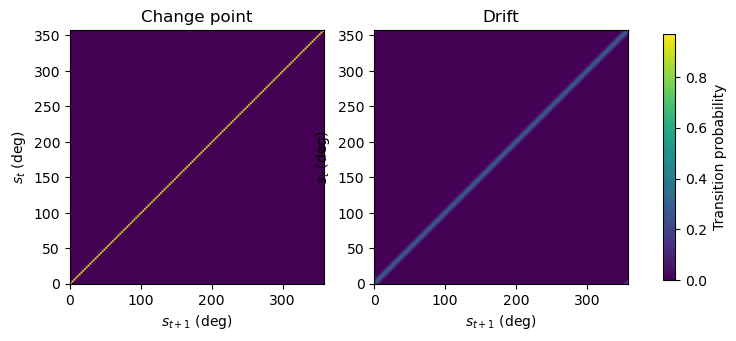

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
vmax = max(Tmat_changepoint.max(), Tmat_drift.max())
for ax, Tmat, title in zip(axes, [Tmat_changepoint, Tmat_drift], ['Change point', 'Drift']):
    im = ax.imshow(Tmat, origin='lower', cmap='viridis', vmin=0, vmax=vmax,
                    extent=[grid_deg[0], grid_deg[-1], grid_deg[0], grid_deg[-1]])
    ax.set_xlabel('$s_{t+1}$ (deg)')
    ax.set_ylabel('$s_t$ (deg)')
    ax.set_title(title)
fig.colorbar(im, ax=axes, label='Transition probability', shrink=0.8)
fig.savefig('output/bayesian_filtering_transition_matrices.svg')

Zoom in the transition matrix

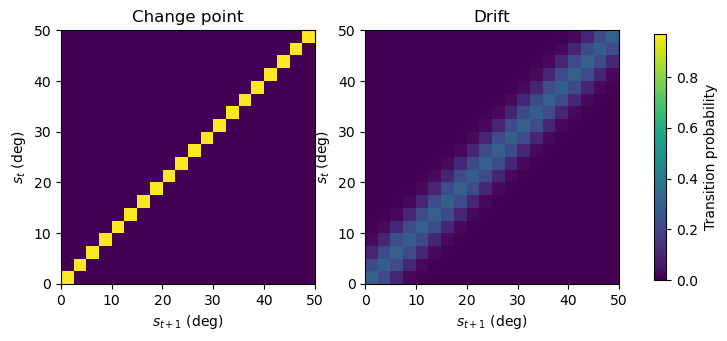

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
vmax = max(Tmat_changepoint.max(), Tmat_drift.max())
dir_max = 20
for ax, Tmat, title in zip(axes, [Tmat_changepoint, Tmat_drift], ['Change point', 'Drift']):
    im = ax.imshow(Tmat[0:dir_max, 0:dir_max], origin='lower', cmap='viridis', vmin=0, vmax=vmax,
                    extent=[grid_deg[0], grid_deg[dir_max], grid_deg[0], grid_deg[dir_max]])
    ax.set_xlabel('$s_{t+1}$ (deg)')
    ax.set_ylabel('$s_t$ (deg)')
    ax.set_title(title)
fig.colorbar(im, ax=axes, label='Transition probability', shrink=0.8)

## Section 4 -- Apparent learning rate

A convenient way to summarize how much an observer updates its belief after each observation and the prediction error it conveys is the **trial-by-trial apparent learning rate** $\alpha_t$:

$$ \alpha_t = \frac{m_{t+1} - m_t}{y_t - m_t} $$

where $m_t$ is the circular-mean belief **just before** observing $y_t$ (the predictive mean), and $m_{t+1}$ is its circular-mean belief **just after** incorporating $y_t$ (the posterior mean -- the belief handed on to trial $t+1$, before the next transition/prediction step). The difference $y_t - m_t$ is the prediction error that motivates the learner to update its belief. 

We say *apparent* learning rate because this quantity can be computed for any algorithm that returns an estimate $m_t$ on each trial $t$, even when there is no internal parameter in this algorithm that correspond to a learning rate. 

There is one famous, simple and efficient learning algorithm that features a learning rate parameter, namely the *delta rule*. In the delta rule, the update is proportional to the prediction error, with a proportionality factor that is the learning rate (which in the simplest algorithm is constant):

$m_{t+1} = m_t + \alpha (y_t - m_t)$

Technical note: because the apparent learning rate is is a ratio, it blows up whenever the denominator $y_t - m_t$ is close to zero. We use three safeguards: (1) trials with $|y_t - m_t|$ below a small threshold are excluded (set to NaN) rather than kept as a biased, near-infinite ratio; (2) the very first trial is always excluded, since the initial uniform prior has no meaningful circular mean; (3) the remaining per-trial ratios are clipped. We average with `np.nanmean` and can inspect the excluded fraction as a diagnostic.

In [16]:
def apparent_learning_rate(y, prior_mean, post_mean, min_abs_pe=5.0, clip_lr=5.0, period=360.0):
    """Per-trial and mean apparent learning rate:
        LR_t = circ_diff(post_mean_t, prior_mean_t) / circ_diff(y_t, prior_mean_t)
    Excludes trial 0 (flat-prior circular mean is undefined) and trials with
    |circ_diff(y_t, prior_mean_t)| < min_abs_pe (near 0/0, -> NaN); remaining values are
    clipped to +-clip_lr. Returns (lr_trials, lr_mean, frac_excluded)."""
    y = np.asarray(y, dtype=float)
    prior_mean = np.asarray(prior_mean, dtype=float)
    post_mean = np.asarray(post_mean, dtype=float)
    pe = circ_diff(y, prior_mean, period)
    upd = circ_diff(post_mean, prior_mean, period)
    with np.errstate(divide='ignore', invalid='ignore'):
        lr = upd / pe
    lr[0] = np.nan
    lr[np.abs(pe) < min_abs_pe] = np.nan
    lr = np.clip(lr, -clip_lr, clip_lr)
    frac_excluded = float(np.mean(np.isnan(lr)))
    return lr, float(np.nanmean(lr)), frac_excluded


def delta_rule(y, learning_rate, m0=None, period=360.0):
    """Circular delta-rule: m_hat[0] = m0 (defaults to y[0]); for t>=1,
    m_hat[t] = m_hat[t-1] + learning_rate * circ_diff(y[t], m_hat[t-1]), wrapped to
    [0, period)."""
    y = np.asarray(y, dtype=float)
    T_obs = len(y)
    m = np.zeros(T_obs)
    m_prev = y[0] if m0 is None else m0
    m[0] = m_prev
    for t in range(1, T_obs):
        m_prev = (m_prev + learning_rate * circ_diff(y[t], m_prev, period)) % period
        m[t] = m_prev
    return m

### How does the optimal (i.e. Bayesian) apparent learning rate depend on volatility and stochasticity?

The goal is to identify how the apparent learning rate changes across volatility and stochasticity levels. To do so, we run many simulated sequences per parameter value and average the apparent learning rate, separately for the change-point and drift regimes:

1. Learning rate as a function of volatility (change-point probability, or drift SD), at a fixed stochasticity.
2. Learning rate as a function of stochasticity (observation-noise SD), at a fixed volatility.

We expect the apparent learning rate to **increase with volatility** (a more volatile world renders previous observations more quickly obsolete, which calls for weighting new observations more) and to **decrease with stochasticity** (noisier observations are less informative about the latent states, they should be trusted less).

In [17]:
def run_sweep(grid_deg, volatility_type, volatility_values, sigma_obs_values, T_sweep=150, n_reps=30, period=360.0):
    """Average apparent learning rate (mean +- SEM) as a function of one swept dimension
    (volatility_values or sigma_obs_values); the other argument is a fixed scalar and is
    broadcast. Simulates n_reps sequences of length T_sweep per parameter value."""
    volatility_values = np.atleast_1d(volatility_values).astype(float)
    sigma_obs_values = np.atleast_1d(sigma_obs_values).astype(float)
    n = max(len(volatility_values), len(sigma_obs_values))
    if len(volatility_values) == 1:
        volatility_values = np.full(n, volatility_values[0])
    if len(sigma_obs_values) == 1:
        sigma_obs_values = np.full(n, sigma_obs_values[0])

    means, sems = np.zeros(n), np.zeros(n)
    for i in range(n):
        vparam, sigma_obs = volatility_values[i], sigma_obs_values[i]
        Tmat = build_transition_matrix(grid_deg, volatility_type, vparam, period)
        lrs = np.zeros(n_reps)
        # iterate over simulated sequence (to obtain a stable, mean result)
        for r in range(n_reps):
            seq = generate_sequence(T_sweep, volatility_type, vparam, sigma_obs, period=period)
            posteriors, priors = bayesian_inference(seq['y'], grid_deg, Tmat, sigma_obs)
            prior_mean = circular_mean(grid_deg, priors, period)
            post_mean = circular_mean(grid_deg, posteriors, period)
            _, lr_mean, _ = apparent_learning_rate(seq['y'], prior_mean, post_mean, period=period)
            lrs[r] = lr_mean
        means[i] = np.nanmean(lrs)
        sems[i] = np.nanstd(lrs) / np.sqrt(max(1, np.sum(~np.isnan(lrs))))
    return means, sems

In [46]:
np.random.seed(4)
sigma_obs_fixed = 15.0
p_cp_values = np.array([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5])
sigma_drift_values = np.array([1, 2, 5, 10, 20, 30, 45, 60])
sigma_obs_values = np.array([2, 5, 10, 15, 20, 30, 45, 60])

lr_cp_vs_vol, sem_cp_vs_vol = run_sweep(grid_deg, 'changepoint', p_cp_values, sigma_obs_fixed)
lr_drift_vs_vol, sem_drift_vs_vol = run_sweep(grid_deg, 'drift', sigma_drift_values, sigma_obs_fixed)
lr_cp_vs_noise, sem_cp_vs_noise = run_sweep(grid_deg, 'changepoint', 0.05, sigma_obs_values)
lr_drift_vs_noise, sem_drift_vs_noise = run_sweep(grid_deg, 'drift', 10.0, sigma_obs_values)

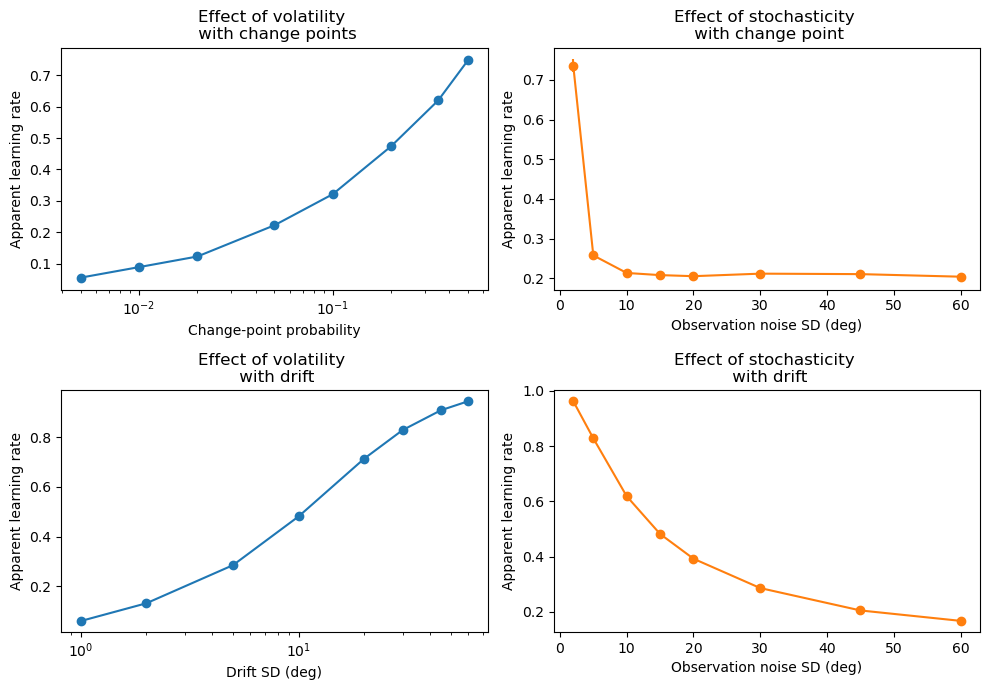

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].errorbar(p_cp_values, lr_cp_vs_vol, yerr=sem_cp_vs_vol, marker='o')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Change-point probability')
axes[0, 0].set_ylabel('Apparent learning rate')
axes[0, 0].set_title('Effect of volatility \n with change points')

axes[0, 1].errorbar(sigma_obs_values, lr_cp_vs_noise, yerr=sem_cp_vs_noise, marker='o', color='tab:orange')
axes[0, 1].set_xlabel('Observation noise SD (deg)')
axes[0, 1].set_ylabel('Apparent learning rate')
axes[0, 1].set_title('Effect of stochasticity \n with change point')

axes[1, 0].errorbar(sigma_drift_values, lr_drift_vs_vol, yerr=sem_drift_vs_vol, marker='o')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Drift SD (deg)')
axes[1, 0].set_ylabel('Apparent learning rate')
axes[1, 0].set_title('Effect of volatility \n with drift')

axes[1, 1].errorbar(sigma_obs_values, lr_drift_vs_noise, yerr=sem_drift_vs_noise, marker='o', color='tab:orange')
axes[1, 1].set_xlabel('Observation noise SD (deg)')
axes[1, 1].set_ylabel('Apparent learning rate')
axes[1, 1].set_title('Effect of stochasticity \n with drift')

fig.tight_layout()
fig.savefig('output/bayesian_filtering_apparent_learning_rate_sweeps.svg')

### Comparing the Bayesian inference to a delta rule

For a few example combinations of volatility (low / medium / high) at a fixed, moderate stochasticity, we compare the Bayesian posterior mean to a simple **delta rule** with a *fixed* learning rate equal to that of the Bayesian mean apparent learning rate.

In [20]:
sigma_obs_example = 15.0
T_example = 100

example_conditions = {
    ('changepoint', 'low'): 0.01,
    ('changepoint', 'medium'): 0.05,
    ('changepoint', 'high'): 0.2,
    ('drift', 'low'): 2.0,
    ('drift', 'medium'): 10.0,
    ('drift', 'high'): 30.0,
}

np.random.seed(5)
example_results = {}
for (vtype, level), vparam in example_conditions.items():
    Tmat = build_transition_matrix(grid_deg, vtype, vparam)
    seq = generate_sequence(T_example, vtype, vparam, sigma_obs_example)
    posteriors, priors = bayesian_inference(seq['y'], grid_deg, Tmat, sigma_obs_example)
    prior_mean = circular_mean(grid_deg, priors)
    post_mean = circular_mean(grid_deg, posteriors)
    _, lr_mean, _ = apparent_learning_rate(seq['y'], prior_mean, post_mean)
    delta_traj = delta_rule(seq['y'], lr_mean)
    example_results[(vtype, level)] = dict(seq=seq, post_mean=post_mean, lr_mean=lr_mean, delta_traj=delta_traj)
    print(f"{vtype:11s} {level:6s}: mean apparent LR = {lr_mean:.3f}")

changepoint low   : mean apparent LR = 0.117
changepoint medium: mean apparent LR = 0.232
changepoint high  : mean apparent LR = 0.505
drift       low   : mean apparent LR = 0.132
drift       medium: mean apparent LR = 0.482
drift       high  : mean apparent LR = 0.828


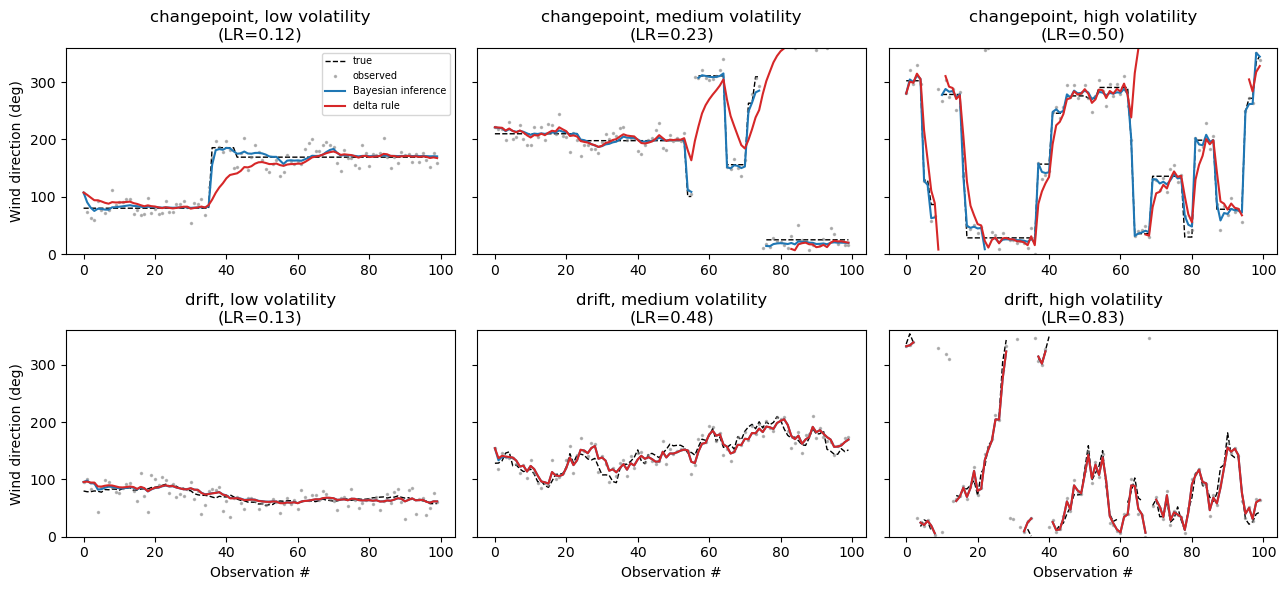

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True)
for row, vtype in enumerate(['changepoint', 'drift']):
    for col, level in enumerate(['low', 'medium', 'high']):
        ax = axes[row, col]
        res = example_results[(vtype, level)]
        seq = res['seq']
        ax.plot(break_circular_line(seq['s']), 'k--', linewidth=1, label='true')
        ax.plot(seq['y'], '.', color='tab:gray', alpha=0.5, markersize=3, label='observed')
        ax.plot(break_circular_line(res['post_mean']), color='tab:blue', label='Bayesian inference')
        ax.plot(break_circular_line(res['delta_traj']), color='tab:red', label='delta rule')
        ax.set_title(f"{vtype}, {level} volatility\n(LR={res['lr_mean']:.2f})")
        ax.set_ylim(0, 360)
        if row == 1:
            ax.set_xlabel('Observation #')
        if col == 0:
            ax.set_ylabel('Wind direction (deg)')
axes[0, 0].legend(loc='upper right', fontsize=7)
fig.tight_layout()
fig.savefig('output/bayesian_filtering_delta_rule_examples.svg')

### Delta rule vs. Bayesian inference: quantifying the mismatch

For each condition, we repeat the simulation many times and compute the (circular) root mean square error (RMSE, which quantifies disagreement) between the Bayesian posterior mean and the delta rule estimate (using for the delta rule the mean apparent learning rate of the Bayesian algorithm for each sequence). We expect the delta rule to track Bayesian inference more closely for **drift** than for **change points** because a fixed learning rate cannot reproduce the occasional large, discrete jump Bayesian inference makes right after a change point.

In [48]:
n_reps_rmse = 30

rmse_results = {cond: [] for cond in example_conditions}
np.random.seed(6)
for (vtype, level), vparam in example_conditions.items():
    Tmat = build_transition_matrix(grid_deg, vtype, vparam)
    for r in range(n_reps_rmse):
        seq = generate_sequence(T_example, vtype, vparam, sigma_obs_example)
        posteriors, priors = bayesian_inference(seq['y'], grid_deg, Tmat, sigma_obs_example)
        prior_mean = circular_mean(grid_deg, priors)
        post_mean = circular_mean(grid_deg, posteriors)
        _, lr_mean, _ = apparent_learning_rate(seq['y'], prior_mean, post_mean)
        delta_traj = delta_rule(seq['y'], lr_mean)
        diff = circ_diff(post_mean[1:], delta_traj[1:])
        rmse_results[(vtype, level)].append(np.sqrt(np.mean(diff ** 2)))

rmse_mean = {c: np.mean(v) for c, v in rmse_results.items()}
rmse_sem = {c: np.std(v) / np.sqrt(len(v)) for c, v in rmse_results.items()}

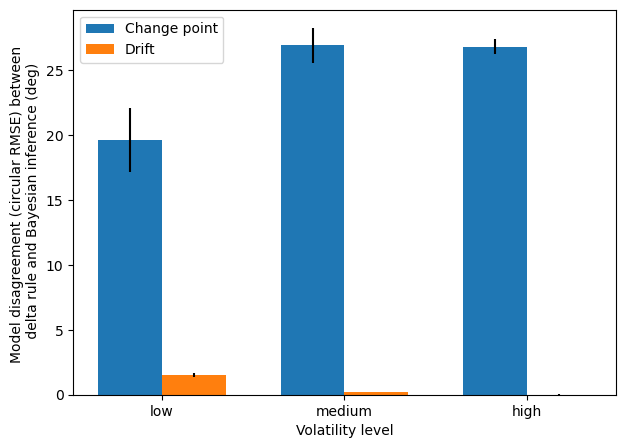

In [50]:
levels = ['low', 'medium', 'high']
x = np.arange(len(levels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width / 2, [rmse_mean[('changepoint', lv)] for lv in levels],
       width, yerr=[rmse_sem[('changepoint', lv)] for lv in levels], label='Change point', color='tab:blue')
ax.bar(x + width / 2, [rmse_mean[('drift', lv)] for lv in levels],
       width, yerr=[rmse_sem[('drift', lv)] for lv in levels], label='Drift', color='tab:orange')
ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_xlabel('Volatility level')
ax.set_ylabel('Model disagreement (circular RMSE) between \n delta rule and Bayesian inference (deg)')
ax.legend()
fig.savefig('output/bayesian_filtering_delta_rule_rmse.svg')

Across both regimes, the delta rule with a well-chosen fixed learning rate captures much of the Bayesian inference average behavior, but it does so more faithfully for gradual **drift** than for abrupt **change points**, where the optimal observer must occasionally make a much bigger jump than any fixed learning rate would allow. 

If there is a cost to Bayesian inference, then this cost is worth spending more in changing environments than drifting environments. The following paper invistigated whether human participants adjust their inference type to the environment: Tavoni, Gaia, Takahiro Doi, Chris Pizzica, Vijay Balasubramanian, and Joshua I. Gold. 2022. “Human Inference Reflects a Normative Balance of Complexity and Accuracy.” Nature Human Behaviour 6 (8): 1153–68
